In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('/content/student_performance_knn.csv')

In [4]:
df

,Student_ID,Gender,Age,Study_Hours_Per_Day,Attendance_Percentage,Previous_Score,Sleep_Hours,Extra_Curricular_Activities,Internet_Access,Tuition,Parent_Education,Distance_From_School_KM,Final_Score,Grade
0,STU0001,Female,15,4.4,96,61,9.4,Yes,No,No,Primary,3.4,56.2,C
1,STU0002,Male,15,9.6,61,83,8.4,No,No,No,Postgraduate,1.8,67.1,C
2,STU0003,Female,17,7.6,65,97,5.1,No,No,Yes,Graduate,14.7,67.9,C
3,STU0004,Male,15,6.4,73,75,7.7,No,No,No,Postgraduate,11.4,54.6,D
4,STU0005,Female,16,2.4,68,44,6.6,Yes,Yes,Yes,Graduate,7.5,34.1,F
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,STU0996,Male,15,1.8,84,65,7.8,Yes,Yes,Yes,Graduate,17.9,45.6,D
996,STU0997,Female,16,9.3,83,72,9.0,No,Yes,Yes,Secondary,11.6,74.9,B
997,STU0998,Female,18,2.2,72,60,7.0,Yes,Yes,Yes,Secondary,16.3,39.8,F
998,STU0999,Female,18,9.6,79,74,7.2,No,Yes,No,Secondary,16.3,73.0,B


In [5]:
df.drop(columns=['Student_ID'],inplace=True)

In [6]:
df.head()

,Gender,Age,Study_Hours_Per_Day,Attendance_Percentage,Previous_Score,Sleep_Hours,Extra_Curricular_Activities,Internet_Access,Tuition,Parent_Education,Distance_From_School_KM,Final_Score,Grade
0,Female,15,4.4,96,61,9.4,Yes,No,No,Primary,3.4,56.2,C
1,Male,15,9.6,61,83,8.4,No,No,No,Postgraduate,1.8,67.1,C
2,Female,17,7.6,65,97,5.1,No,No,Yes,Graduate,14.7,67.9,C
3,Male,15,6.4,73,75,7.7,No,No,No,Postgraduate,11.4,54.6,D
4,Female,16,2.4,68,44,6.6,Yes,Yes,Yes,Graduate,7.5,34.1,F


In [7]:
df.tail()

,Gender,Age,Study_Hours_Per_Day,Attendance_Percentage,Previous_Score,Sleep_Hours,Extra_Curricular_Activities,Internet_Access,Tuition,Parent_Education,Distance_From_School_KM,Final_Score,Grade
995,Male,15,1.8,84,65,7.8,Yes,Yes,Yes,Graduate,17.9,45.6,D
996,Female,16,9.3,83,72,9.0,No,Yes,Yes,Secondary,11.6,74.9,B
997,Female,18,2.2,72,60,7.0,Yes,Yes,Yes,Secondary,16.3,39.8,F
998,Female,18,9.6,79,74,7.2,No,Yes,No,Secondary,16.3,73.0,B
999,Male,18,5.0,57,91,4.9,Yes,Yes,No,Graduate,4.2,52.9,D


In [8]:
df.shape

(1000, 13)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Gender                       1000 non-null   object 
 1   Age                          1000 non-null   int64  
 2   Study_Hours_Per_Day          1000 non-null   float64
 3   Attendance_Percentage        1000 non-null   int64  
 4   Previous_Score               1000 non-null   int64  
 5   Sleep_Hours                  1000 non-null   float64
 6   Extra_Curricular_Activities  1000 non-null   object 
 7   Internet_Access              1000 non-null   object 
 8   Tuition                      1000 non-null   object 
 9   Parent_Education             1000 non-null   object 
 10  Distance_From_School_KM      1000 non-null   float64
 11  Final_Score                  1000 non-null   float64
 12  Grade                        1000 non-null   object 
dtypes: float64(4), int6

In [11]:
df.isnull().sum()

,0
Gender,0
Age,0
Study_Hours_Per_Day,0
Attendance_Percentage,0
Previous_Score,0
Sleep_Hours,0
Extra_Curricular_Activities,0
Internet_Access,0
Tuition,0
Parent_Education,0


In [12]:
df.describe()

,Age,Study_Hours_Per_Day,Attendance_Percentage,Previous_Score,Sleep_Hours,Distance_From_School_KM,Final_Score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,17.062000,5.413500,74.695000,69.326000,7.049600,10.394500,53.061600
std,1.421329,2.630701,14.497453,17.278665,1.742101,5.642701,15.472739
min,15.000000,1.000000,50.000000,40.000000,4.000000,0.600000,0.000000
25%,16.000000,3.100000,62.000000,55.000000,5.500000,5.700000,41.875000
50%,17.000000,5.500000,75.000000,69.000000,7.200000,10.500000,53.600000
75%,18.000000,7.700000,87.000000,84.000000,8.600000,15.400000,64.225000
max,19.000000,10.000000,99.000000,99.000000,10.000000,20.000000,100.000000


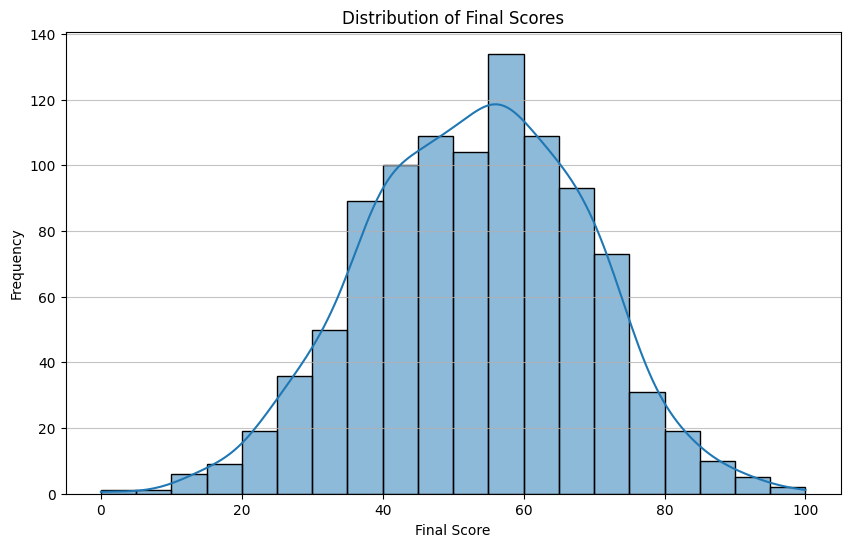

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Final_Score'], kde=True, bins=20)
plt.title('Distribution of Final Scores')
plt.xlabel('Final Score')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

The histogram above shows the distribution of final scores. It appears to be somewhat normally distributed, possibly with a slight skew, and covers a range from 0 to 100.

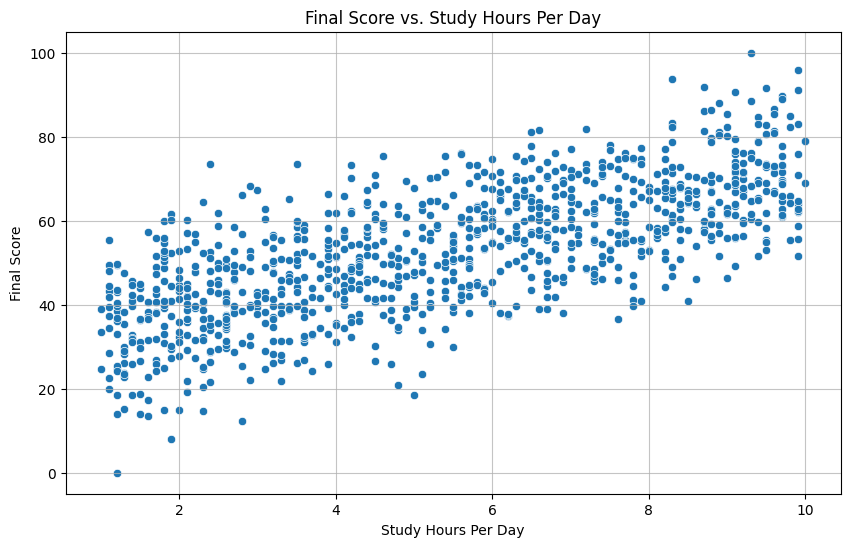

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Study_Hours_Per_Day', y='Final_Score', data=df)
plt.title('Final Score vs. Study Hours Per Day')
plt.xlabel('Study Hours Per Day')
plt.ylabel('Final Score')
plt.grid(True, alpha=0.75)
plt.show()

This scatter plot shows the relationship between study hours per day and final scores. It generally suggests a positive correlation: students who study more tend to have higher final scores, though there's still variability.

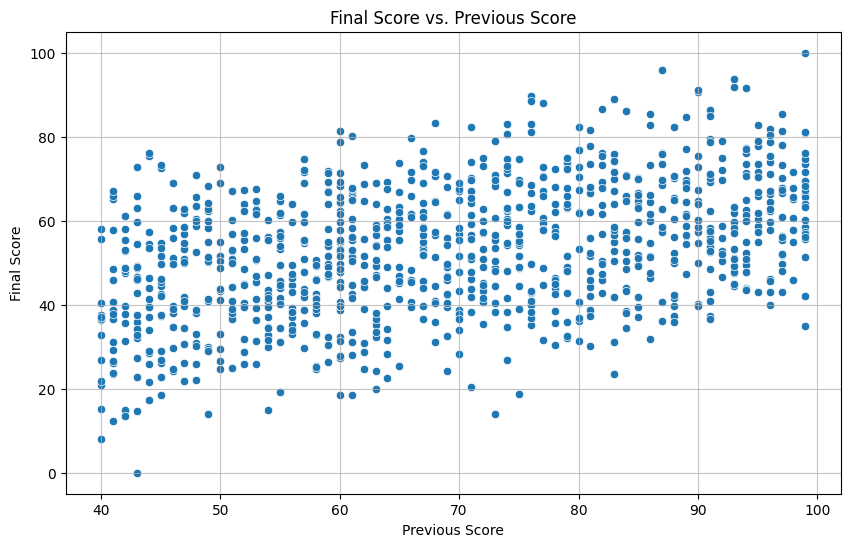

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Previous_Score', y='Final_Score', data=df)
plt.title('Final Score vs. Previous Score')
plt.xlabel('Previous Score')
plt.ylabel('Final Score')
plt.grid(True, alpha=0.75)
plt.show()

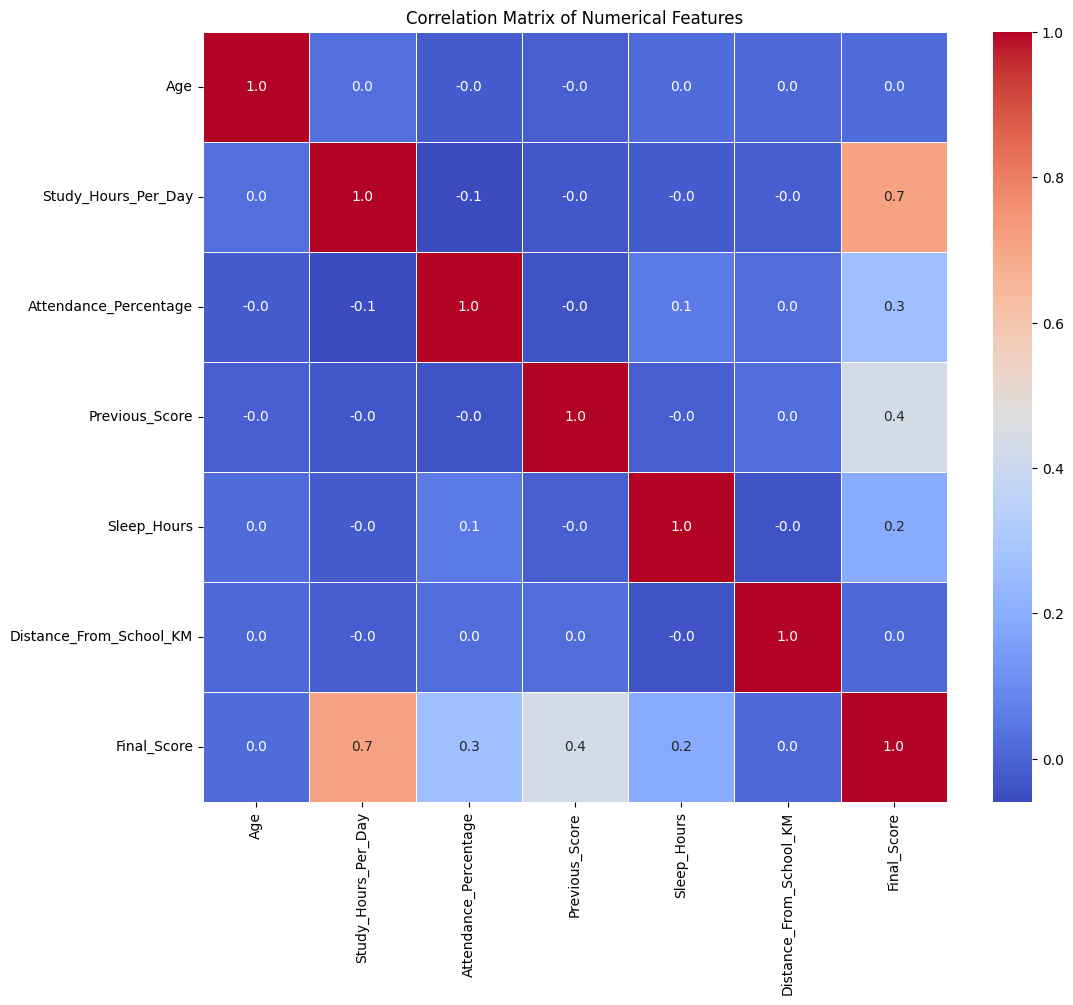

In [16]:
numerical_cols = df.select_dtypes(include=np.number).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.1f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

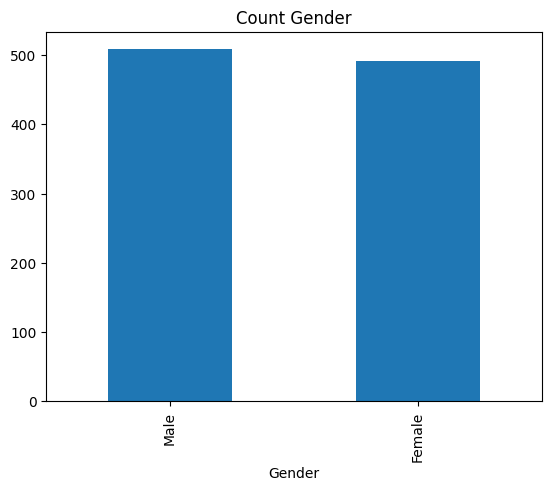

In [17]:
df['Gender'].value_counts().plot(kind='bar')
plt.title('Count Gender')
plt.show()

In [18]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [19]:
le = LabelEncoder()

In [20]:
df['Gender'] = le.fit_transform(df['Gender'])
df['Extra_Curricular_Activities'] = le.fit_transform(df['Extra_Curricular_Activities'])
df['Internet_Access'] = le.fit_transform(df['Internet_Access'])
df['Tuition'] = le.fit_transform(df['Tuition'])
df['Parent_Education'] = le.fit_transform(df['Parent_Education'])

In [21]:
X = df.drop(columns=['Grade'])
y = df['Grade']

In [22]:
y_encoded = le.fit_transform(y)
class_names = le.classes_

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
X_train,X_test,y_train,y_test = train_test_split(X,y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

In [25]:
scaler = StandardScaler()
X_train_Scaled = scaler.fit_transform(X_train)
X_test_Scaled = scaler.transform(X_test)

In [33]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score, recall_score, precision_score

In [29]:
models = {
    'KNN'          : KNeighborsClassifier(n_neighbors=best_k),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost'      : XGBClassifier(random_state=42)
}

In [32]:
for name, model in models.items():
    model.fit(X_train_Scaled, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_Scaled))
    print(f"{name:15s} → Accuracy: {acc:.4f}")

KNN             → Accuracy: 0.6300
Random Forest   → Accuracy: 0.9850
XGBoost         → Accuracy: 0.9900


In [35]:
y_pred = models['XGBoost'].predict(X_test_Scaled)
print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

           A       1.00      1.00      1.00         3
           B       0.93      1.00      0.96        25
           C       1.00      0.97      0.98        67
           D       1.00      1.00      1.00        63
           F       1.00      1.00      1.00        42

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200



In [36]:
f1 = f1_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall Score: {recall:.4f}")

F1 Score: 0.9901
Precision: 0.9907
Recall Score: 0.9900
